In [ ]:
!pip install -r requerients.txt

In [1]:
#Necesary libraries
import numpy as np
import cmath
import networkx as nx
import matplotlib.pyplot as plt
import itertools 
import json

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit import transpile
from qiskit.visualization import  plot_histogram
from qiskit.quantum_info import state_fidelity,Statevector,partial_trace
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke,FakeBrisbane,FakeKyoto,FakeOsaka,FakeManilaV2,FakeKyiv
from qiskit.quantum_info import negativity




In [2]:
def state_3layers(nq):
    """
    Entangled state with 3 layers
    input:
        nq= qubit number
    Output:
        qc: quantum circuit with 4 layer state
    """
    qr=QuantumRegister(nq,'qr')
    cr=ClassicalRegister(nq,'cr')
    qc=QuantumCircuit(qr,cr)
    if nq%2==0:
        qc.sx(list(range(nq)))
    else:
        qc.sx(list(range(nq-1)))
        qc.x(nq-1)
    for i in range(0,nq-1,2):
        qc.ecr(i,i+1)
    for i in range(1,nq-1,2):    
        qc.ecr(i,i+1)
    #qcf5.sx(0)
    qc.sx(0)
    #for i in range(1,nq):
    #    qc.sx(i)
    return qc

def state_4layers(nq):
    """
    Entangled state with 4 layers
    input:
        nq= qubit number
    Output:
        qc: quantum circuit with 4 layer state
    """
    qr=QuantumRegister(nq,'qr')
    cr=ClassicalRegister(nq,'cr')
    qc=QuantumCircuit(qr,cr)
    qc.sx(list(range(nq)))
    for i in range(0,nq-1,2):
        qc.ecr(i,i+1)
    for i in range(1,nq-1,2):    
        qc.ecr(i,i+1)
    #qcf5.sx(0)
    for i in range(1,nq):
        qc.sx(i)
    return qc


        


# Dataset Load for 2n+1 basis results

In [21]:
with open('res_kyo_w_err_f.txt') as f:
        data_w_err_kyoto = json.load(f)
        
data_for_plot_kyoto=(data_w_err_kyoto.values())

res_kyo_3=[]
err_kyo_3=[]
for data,err in data_for_plot_kyoto:
    res_kyo_3.append(data)
    err_kyo_3.append(err)
    
with open('res_sher_w_err_f.txt') as f:
        data_w_err_sher = json.load(f)
    
data_for_plot_sher=(data_w_err_sher.values())
res_sher_3=[]
err_sher_3=[]
for data,err in data_for_plot_sher:
    res_sher_3.append(data)
    err_sher_3.append(err)
    
with open('res_kyiv_w_err_f.txt') as f:
        data_w_err_kyiv = json.load(f)

my_dict=data_w_err_kyiv
data_for_plot_kyiv=(data_w_err_kyiv.values())

res_kyiv_3=[]
err_kyiv_3=[]
for data,err in data_for_plot_kyiv:
    res_kyiv_3.append(data)
    err_kyiv_3.append(err)


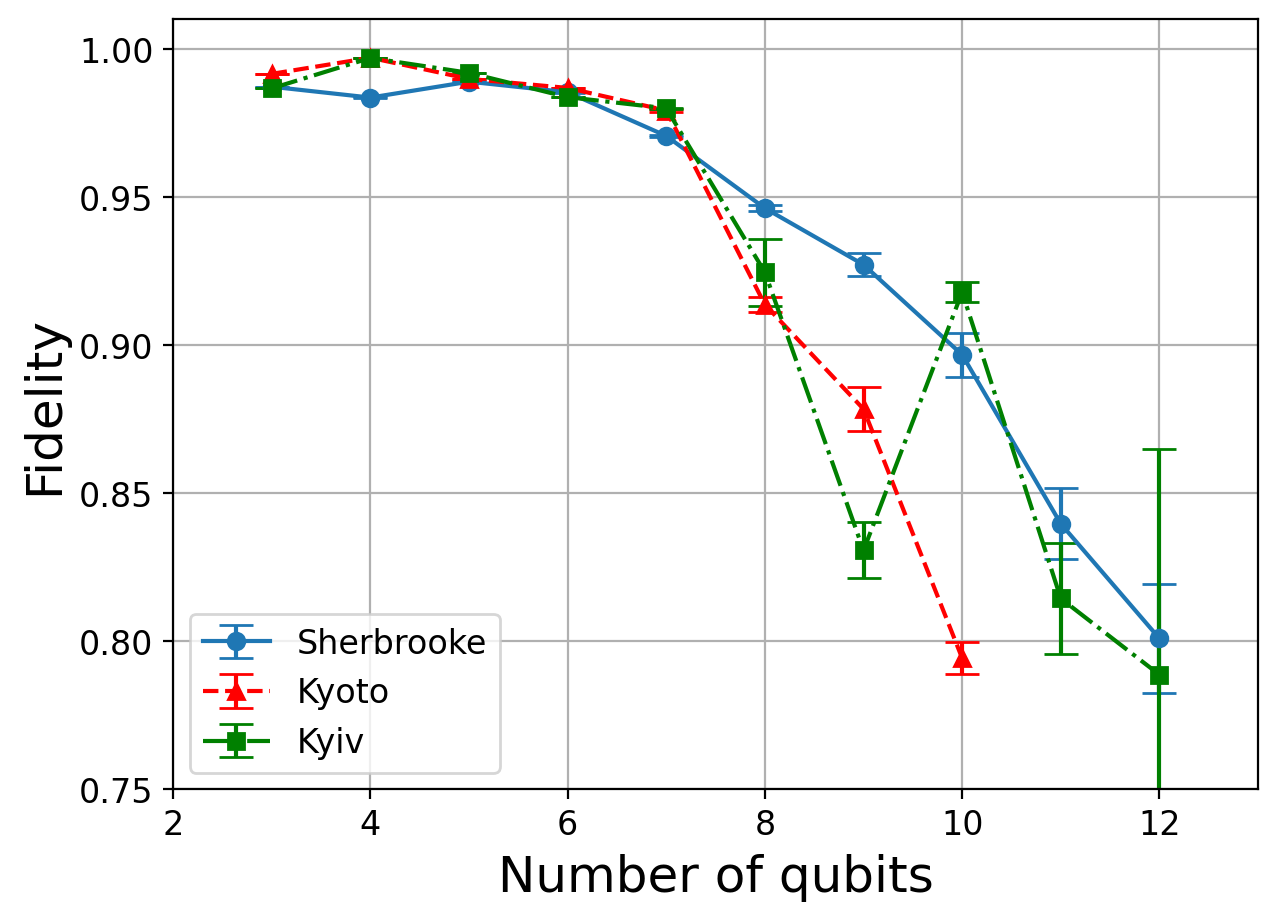

In [49]:
xtics=list(range(3,13))

plt.figure(figsize=(7,5), dpi=200)

plt.errorbar(xtics,res_sher_3,yerr=err_sher_3,marker='o',label="Sherbrooke",capsize=6,capthick=1)
xtics=list(range(3,11))
plt.errorbar(xtics,res_kyo_3,yerr=err_kyo_3,marker='^',label="Kyoto",color='r', linestyle='--',capsize=6,capthick=1)
xtics=list(range(3,13))
plt.errorbar(xtics,res_kyiv_3,yerr=err_kyiv_3,marker='s',label="Kyiv",color='g', linestyle='-.',capsize=6,capthick=1)

#plt.errorbar(xtics,fids_7,yerr=fids_7_std,marker='o',capsize=3,label="7 qubits")
#plt.errorbar(xtics,fids_8,yerr=fids_8_std,marker='o',capsize=3,label="8 qubits")
#plt.errorbar(xtics,fids_9,yerr=fids_9_std,marker='o',capsize=3,label="9 qubits")
#plt.errorbar(xtics,fids_10,yerr=fids_10_std,marker='o',capsize=3,label="10 qubits")


plt.ylim((0.75,1.01))
plt.yticks([0.75,0.80,0.85,0.90,0.95,1.0], fontsize=12)
plt.xticks(fontsize=12)
plt.xlim((2,13))
plt.xlabel(r'Number of qubits', fontsize=18)
plt.ylabel(r'Fidelity',fontsize=18)
plt.legend(fontsize=12, loc='lower left')
#plt.title(r'Fidelity vs. Qubit number IBM Eagle QPUs')
plt.grid(True)


plt.savefig(
    'Res_10_11.png',          # Filename (can include path)
    dpi=300,               # Dots per inch (resolution)
    bbox_inches='tight',   # Minimize whitespace around plot
    #quality=95,            # For JPEG only (1-100)
    transparent=True,      # Make background transparent
    facecolor='white'      # Figure face color
)
plt.show()


# Dataset load for comparison with 5 bases protocol
 
## Same ensemble size  $N=5(2\times 10^4)$

## Kyoto:

In [23]:

import json

with open('res_kyo_2n_SS_w_err.txt') as f:
        data_w2n_SS_err = json.load(f)

data_for_plot_2nSS=(data_w2n_SS_err.values())
res_kyo_2n_SS=[]
err_kyo_2n_SS=[]
for data,err in list(data_for_plot_2nSS):
    res_kyo_2n_SS.append(data)
    err_kyo_2n_SS.append(err)
    
import json

with open('res_kyo_5b_w_err.txt') as f:
        data_w5b_SS_err = json.load(f)

data_for_plot_5bSS=(data_w5b_SS_err.values())
res_kyo_5b_SS=[]
err_kyo_5b_SS=[]
for data,err in list(data_for_plot_5bSS):
    res_kyo_5b_SS.append(data)
    err_kyo_5b_SS.append(err)

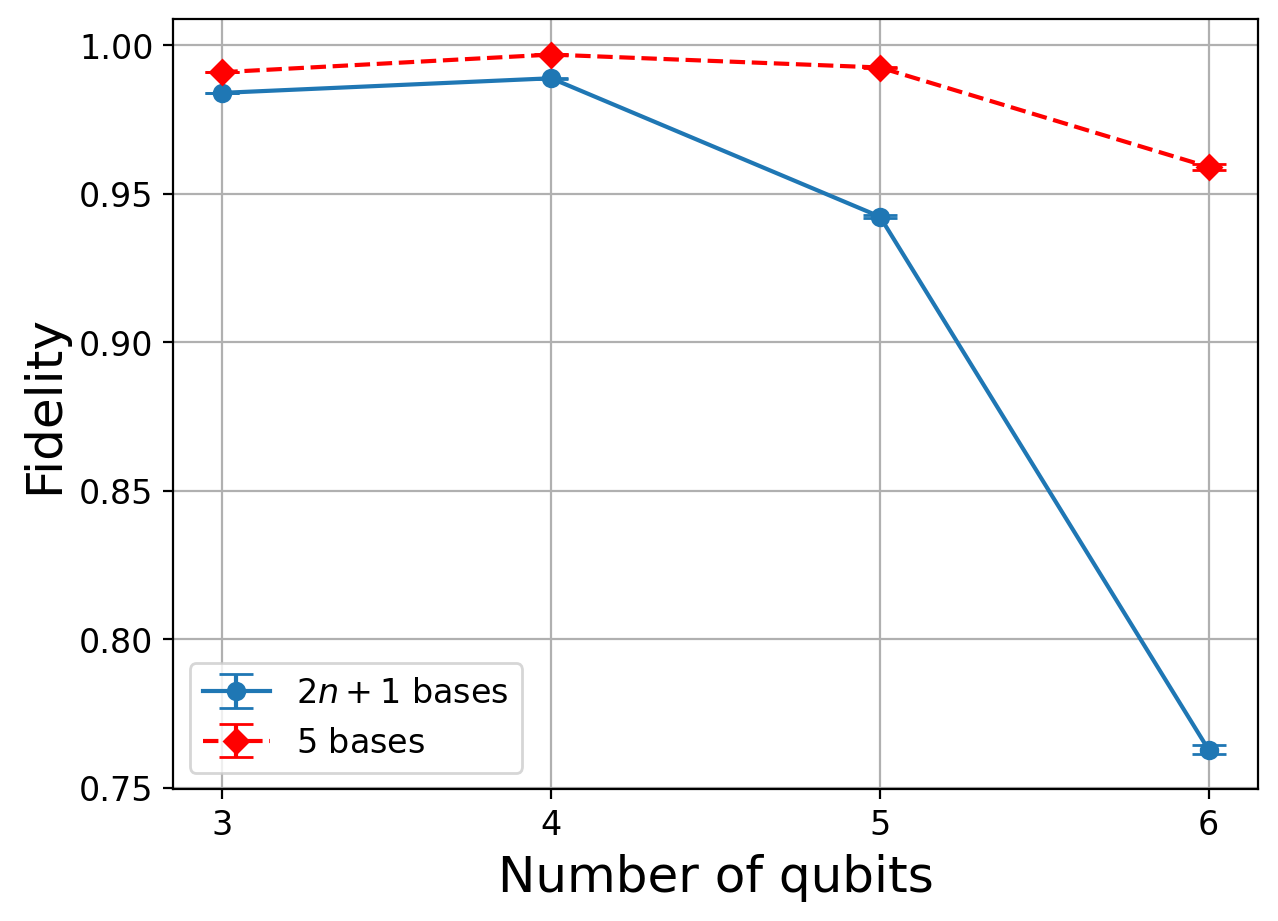

In [50]:
xtics=list(range(3,7))#3print(len(xtics))
plt.figure(figsize=(7,5), dpi=200)
plt.errorbar(xtics,res_kyo_2n_SS[0:4],yerr=err_kyo_2n_SS[0:4],capsize=6,marker='o',label=r"$2n+1$ bases")

plt.errorbar(xtics,res_kyo_5b_SS[0:4],yerr=err_kyo_5b_SS[0:4],capsize=6,marker='D',label="$5$ bases",color='r', linestyle='--')

#plt.errorbar(xtics,fids_7,yerr=fids_7_std,marker='o',capsize=3,label="7 qubits")
#plt.errorbar(xtics,fids_8,yerr=fids_8_std,marker='o',capsize=3,label="8 qubits")
#plt.errorbar(xtics,fids_9,yerr=fids_9_std,marker='o',capsize=3,label="9 qubits")
#plt.errorbar(xtics,fids_10,yerr=fids_10_std,marker='o',capsize=3,label="10 qubits")



plt.xlabel('Number of qubits', fontsize=18)
plt.xticks(list(range(3,7)),fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Fidelity', fontsize=18)
plt.legend(fontsize=12, loc='lower left')
#plt.title('Fidelity vs. Qubit Number for Kyoto QPU (Same shots per basis)')
plt.grid(True)

plt.savefig(
    'Kyoto_same_size.png',          # Filename (can include path)
    dpi=300,               # Dots per inch (resolution)
    bbox_inches='tight',   # Minimize whitespace around plot
    #quality=95,            # For JPEG only (1-100)
    transparent=True,      # Make background transparent
    facecolor='white'      # Figure face color
)

plt.show()

## Same ensemble size  $N=5(2\times 10^4)$

## Kyiv:

In [25]:
import json

with open('res_kyiv_2n_SS_w_err.txt') as f:
        data_w2n_SS_err = json.load(f)

data_for_plot_2nSS=(data_w2n_SS_err.values())
res_kyiv_2n_SS=[]
err_kyiv_2n_SS=[]
for data,err in list(data_for_plot_2nSS):
    res_kyiv_2n_SS.append(data)
    err_kyiv_2n_SS.append(err)
    
import json

with open('res_kyiv_5b_w_err.txt') as f:
        data_w5b_SS_err = json.load(f)

data_for_plot_5bSS=(data_w5b_SS_err.values())
res_kyiv_5b_SS=[]
err_kyiv_5b_SS=[]
for data,err in list(data_for_plot_5bSS):
    res_kyiv_5b_SS.append(data)
    err_kyiv_5b_SS.append(err)

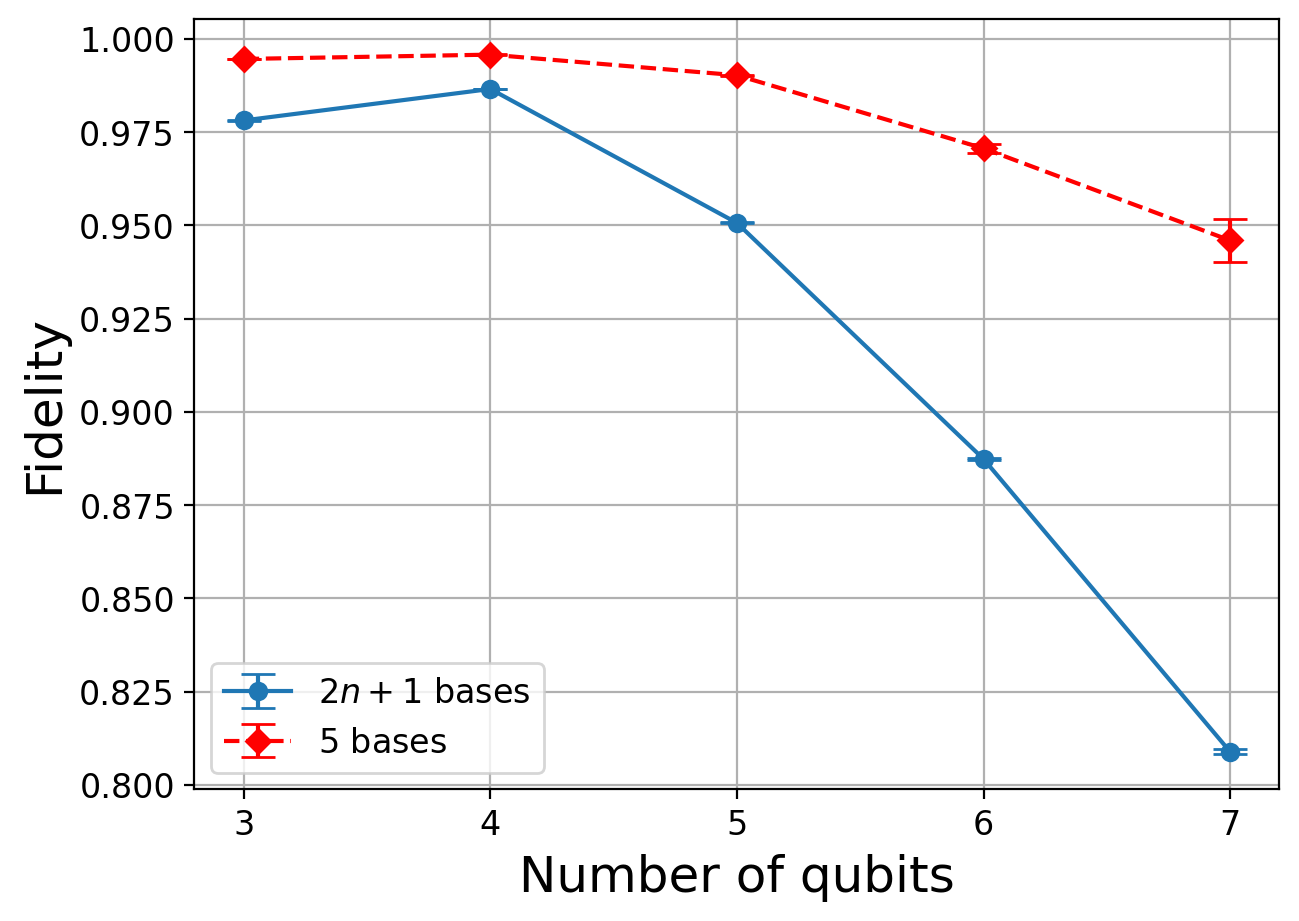

In [51]:
xtics=list(range(3,8))
plt.figure(figsize=(7,5), dpi=200)
plt.errorbar(xtics,res_kyiv_2n_SS[0:5],yerr=err_kyiv_2n_SS[0:5],capsize=6,marker='o',label=r"$2n+1$ bases")
plt.errorbar(xtics,res_kyiv_5b_SS[0:5],yerr=err_kyiv_5b_SS[0:5],capsize=6,marker='D',label="$5$ bases",color='r', linestyle='--')


#plt.errorbar(xtics,fids_7,yerr=fids_7_std,marker='o',capsize=3,label="7 qubits")
#plt.errorbar(xtics,fids_8,yerr=fids_8_std,marker='o',capsize=3,label="8 qubits")
#plt.errorbar(xtics,fids_9,yerr=fids_9_std,marker='o',capsize=3,label="9 qubits")
#plt.errorbar(xtics,fids_10,yerr=fids_10_std,marker='o',capsize=3,label="10 qubits")



plt.xlabel('Number of qubits', fontsize=18)
plt.xticks(list(range(3,8)),fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Fidelity', fontsize=18)
plt.legend(fontsize=12,loc='lower left')
#plt.title('Fidelity vs. Qubit Number for Kyiv QPU (Same shots per basis)')
plt.grid(True)

plt.savefig(
    'Kyiv_same_size.png',          # Filename (can include path)
    dpi=300,               # Dots per inch (resolution)
    bbox_inches='tight',   # Minimize whitespace around plot
    #quality=95,            # For JPEG only (1-100)
    transparent=True,      # Make background transparent
    facecolor='white'      # Figure face color
)
plt.show()

## Same ensemble size  $N=5(2\times 10^4)$

## Sherbrooke:

In [27]:
import json

with open('res_sher_2n_SS_w_err.txt') as f:
        data_w2n_SS_err = json.load(f)

data_for_plot_2nSS=(data_w2n_SS_err.values())
res_sher_2n_SS=[]
err_sher_2n_SS=[]
for data,err in list(data_for_plot_2nSS):
    res_sher_2n_SS.append(data)
    err_sher_2n_SS.append(err)
    
import json

with open('res_sher_5b_w_err.txt') as f:
        data_w5b_SS_err = json.load(f)

data_for_plot_5bSS=(data_w5b_SS_err.values())
res_sher_5b_SS=[]
err_sher_5b_SS=[]
for data,err in list(data_for_plot_5bSS):
    res_sher_5b_SS.append(data)
    err_sher_5b_SS.append(err)

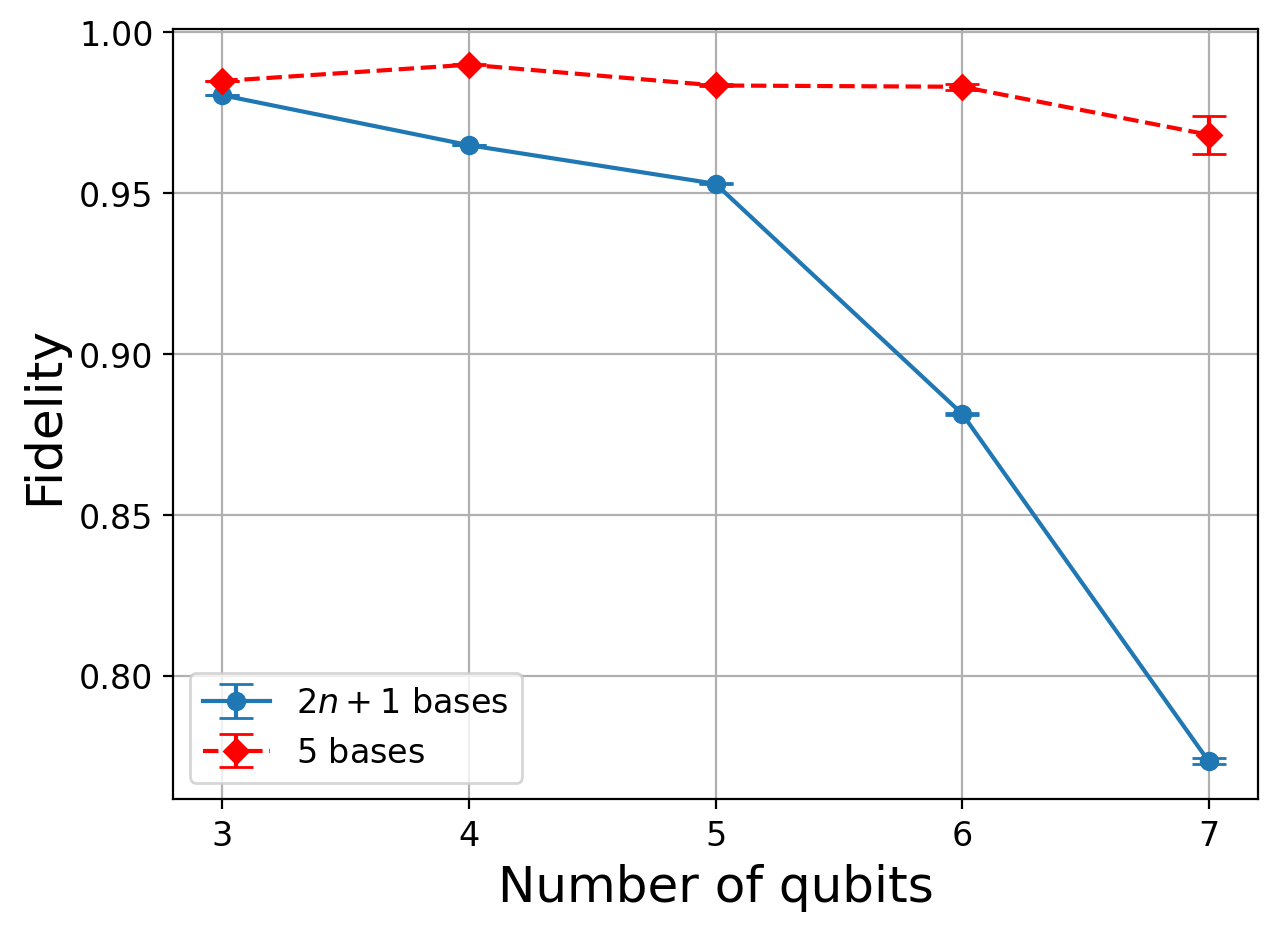

In [52]:
xtics=list(range(3,8))
plt.figure(figsize=(7,5), dpi=200)
plt.errorbar(xtics,res_sher_2n_SS[0:5],yerr=err_sher_2n_SS[0:5],capsize=6,marker='o',label=r"$2n+1$ bases")
plt.errorbar(xtics,res_sher_5b_SS[0:5],yerr=err_sher_5b_SS[0:5],capsize=6,marker='D',label="$5$ bases",color='r', linestyle='--')

#plt.errorbar(xtics,fids_7,yerr=fids_7_std,marker='o',capsize=3,label="7 qubits")
#plt.errorbar(xtics,fids_8,yerr=fids_8_std,marker='o',capsize=3,label="8 qubits")
#plt.errorbar(xtics,fids_9,yerr=fids_9_std,marker='o',capsize=3,label="9 qubits")
#plt.errorbar(xtics,fids_10,yerr=fids_10_std,marker='o',capsize=3,label="10 qubits")



plt.xlabel('Number of qubits', fontsize=18)
plt.xticks(list(range(3,8)), fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Fidelity', fontsize=18)
plt.legend(fontsize=12, loc='lower left')
#plt.title('Fidelity vs. Qubit Number for Sherbrooke QPU (Same shots per basis)')
plt.grid(True)

plt.savefig(
    'Sherbrooke_same_size.png',          # Filename (can include path)
    dpi=300,               # Dots per inch (resolution)
    bbox_inches='tight',   # Minimize whitespace around plot
    #quality=95,            # For JPEG only (1-100)
    transparent=True,      # Make background transparent
    facecolor='white'      # Figure face color
)

plt.show()

# Dataset load for comparison with 5 bases protocol
 
## Same number of experiments on each basis  $N_b=2\times 10^4$

## Kyoto:

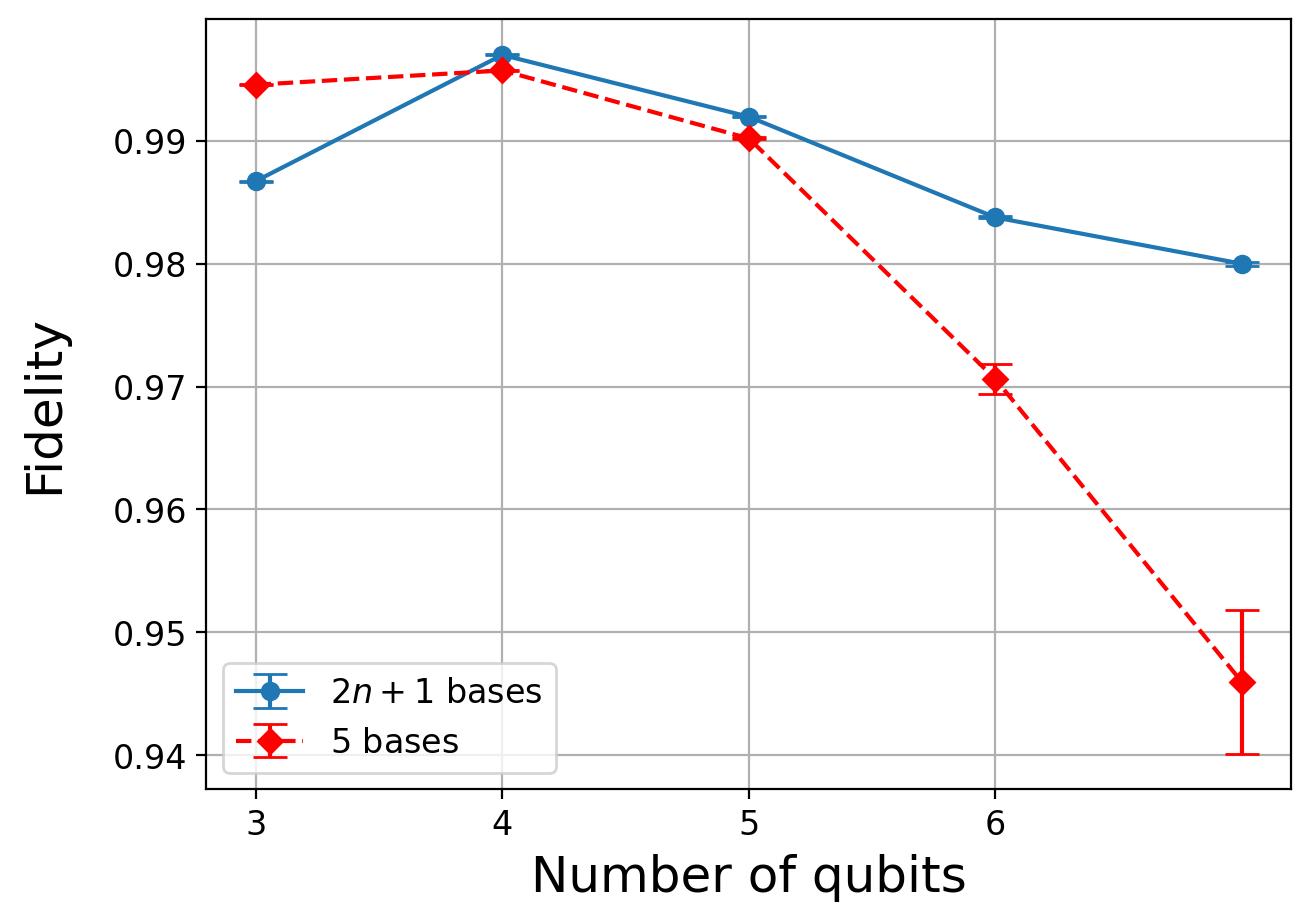

In [53]:
xtics=list(range(3,8))
#fid=[0.8009761854510821,0.8446913481292748,0.8975034602059844,0.9322143887065971,0.9366184588230674]
plt.figure(figsize=(7,5), dpi=200)

plt.errorbar(xtics,res_kyiv_3[0:5],yerr=err_kyiv_3[0:5],marker='o',label="$2n+1$ bases",capsize=6,capthick=1)
plt.errorbar(xtics,res_kyiv_5b_SS[0:5],yerr=err_kyiv_5b_SS[0:5],capsize=6,marker='D',label="$5$ bases",color='r', linestyle='--')
#xtics=list(range(3,7))
#plt.plot(xtics,res_kyoto_LOCC[0:-3],marker='o',label="Kyoto")

#xtics=list(range(3,8))
#plt.plot(xtics,res_kyiv_5b[0:-3],marker='o',label="Kyiv")

#plt.errorbar(xtics,fids_7,yerr=fids_7_std,marker='o',capsize=3,label="7 qubits")
#plt.errorbar(xtics,fids_8,yerr=fids_8_std,marker='o',capsize=3,label="8 qubits")
#plt.errorbar(xtics,fids_9,yerr=fids_9_std,marker='o',capsize=3,label="9 qubits")
#plt.errorbar(xtics,fids_10,yerr=fids_10_std,marker='o',capsize=3,label="10 qubits")


#plt.ylim((0.5,1.05))
#plt.xlim((2,8))
plt.xlabel(r'Number of qubits', fontsize=18)
plt.ylabel(r'Fidelity', fontsize=18,labelpad=16)
plt.xticks(list(range(3,7)),fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='lower left')
#plt.title(r'Fidelity vs. Qubit number for IBM Kyiv QPU (Same ensemble size)')
plt.grid(True)

plt.savefig(
    'Kyiv_same_shots.png',          # Filename (can include path)
    dpi=300,               # Dots per inch (resolution)
    bbox_inches='tight',   # Minimize whitespace around plot
    #quality=95,            # For JPEG only (1-100)
    transparent=True,      # Make background transparent
    facecolor='white'      # Figure face color
)

plt.show()

## Same number of experiments on each basis  $N_b=2\times 10^4$

## Kyiv:

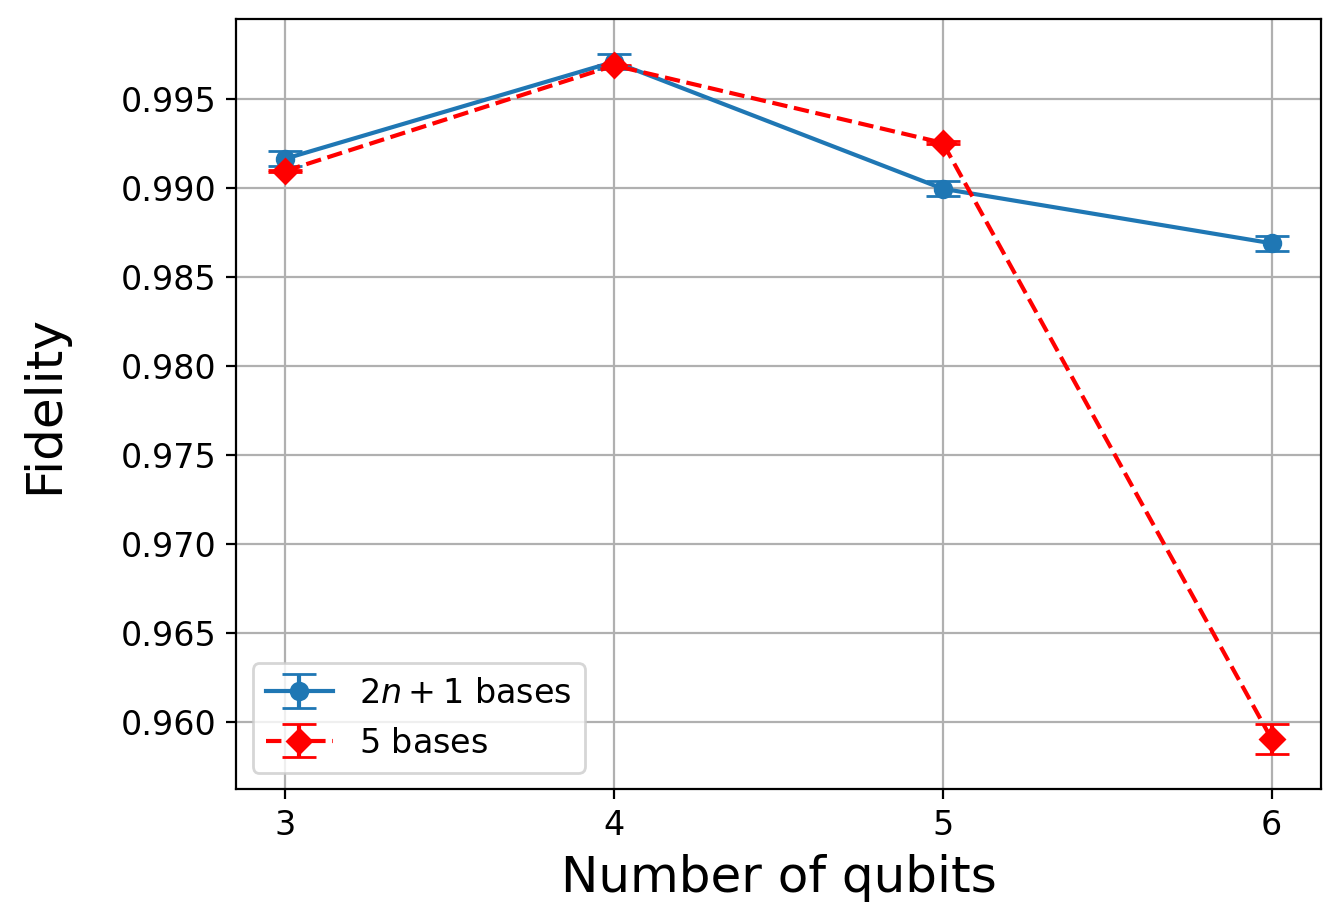

In [54]:
from matplotlib import ticker
xtics=list(range(3,7))
#fid=[0.8009761854510821,0.8446913481292748,0.8975034602059844,0.9322143887065971,0.9366184588230674]
plt.figure(figsize=(7,5), dpi=200)

plt.errorbar(xtics,res_kyo_3[0:4],yerr=err_kyo_3[4],marker='o',label="$2n+1$ bases",capsize=6,capthick=1)
plt.errorbar(xtics,res_kyo_5b_SS[0:4],yerr=err_kyo_5b_SS[0:5],capsize=6,marker='D',label="$5$ bases",color='r', linestyle='--')

#xtics=list(range(3,7))
#plt.plot(xtics,res_kyoto_LOCC[0:-3],marker='o',label="Kyoto")

#xtics=list(range(3,8))
#plt.plot(xtics,res_kyiv_5b[0:-3],marker='o',label="Kyiv")

#plt.errorbar(xtics,fids_7,yerr=fids_7_std,marker='o',capsize=3,label="7 qubits")
#plt.errorbar(xtics,fids_8,yerr=fids_8_std,marker='o',capsize=3,label="8 qubits")
#plt.errorbar(xtics,fids_9,yerr=fids_9_std,marker='o',capsize=3,label="9 qubits")
#plt.errorbar(xtics,fids_10,yerr=fids_10_std,marker='o',capsize=3,label="10 qubits")


#plt.ylim((0.5,1.05))

#plt.xlim((2,7))
plt.xlabel(r'Number of qubits', fontsize=18)
plt.ylabel(r'Fidelity', fontsize=18,labelpad=19)
plt.xticks(list(range(3,7)),fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='lower left')
#plt.title(r'Fidelity vs. Qubit number for IBM Kyoto  QPU (Same ensemble size)')
plt.grid(True)

plt.savefig(
    'Kyoto_same_shots.png',          # Filename (can include path)
    dpi=300,               # Dots per inch (resolution)
    bbox_inches='tight',   # Minimize whitespace around plot
    #quality=95,            # For JPEG only (1-100)
    transparent=True,      # Make background transparent
    facecolor='white'      # Figure face color
)

plt.show()

## Same number of experiments on each basis  $N_b=2\times 10^4$

## Sherbrooke:

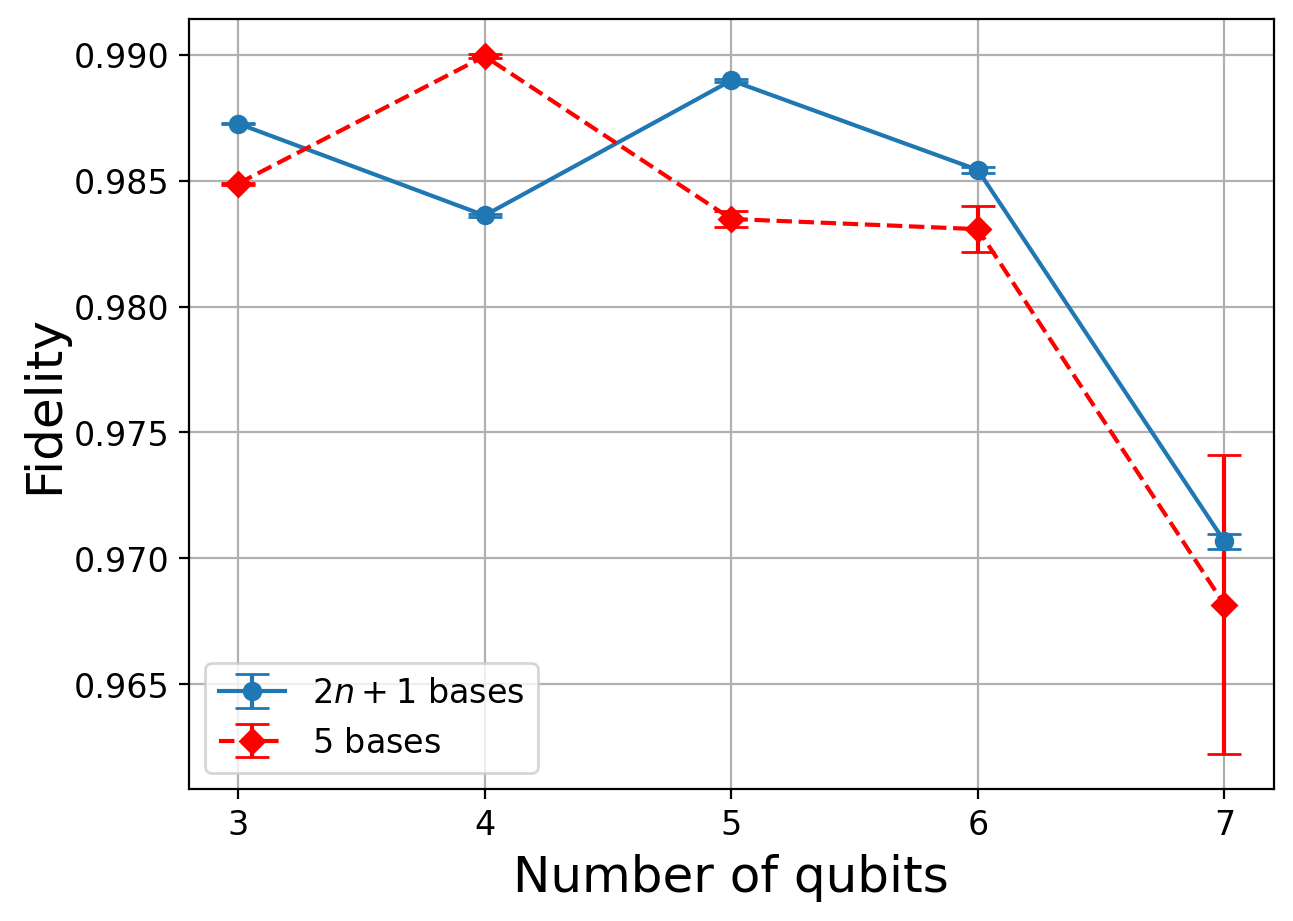

In [55]:
xtics=list(range(3,8))
plt.figure(figsize=(7,5), dpi=200)

plt.errorbar(xtics,res_sher_3[0:5],yerr=err_sher_3[0:5],marker='o',label="$2n+1$ bases",capsize=6,capthick=1)
plt.errorbar(xtics,res_sher_5b_SS[0:5],yerr=err_sher_5b_SS[0:5],capsize=6,marker='D',label="$5$ bases",color='r', linestyle='--')


plt.xlabel(r'Number of qubits', fontsize=18)
plt.ylabel(r'Fidelity', fontsize=18,labelpad=2)
plt.xticks(list(range(3,8)),fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='lower left')
#plt.title(r'Fidelity vs. Qubit number for IBM Sherbrooke  QPU (Same ensemble size)')
plt.grid(True)

plt.savefig(
    'Sherbrooke_same_shots.png',          # Filename (can include path)
    dpi=300,               # Dots per inch (resolution)
    bbox_inches='tight',   # Minimize whitespace around plot
    #quality=95,            # For JPEG only (1-100)
    transparent=True,      # Make background transparent
    facecolor='white'      # Figure face color
)

plt.show()

# Dataset load for 12-qubit system in Sherbrooke Vs. Ensemble Size

In [44]:
#data sherbrook 12 qb
import json

with open('res_sher_12_w_err.txt') as f:
        data_w2n_SS_err = json.load(f)
        
data_for_plot_2nSS=(data_w2n_SS_err.values())
res_sher_2n_12qb=[]
err_sher_2n_12qb=[]
for data,err in list(data_for_plot_2nSS):
    res_sher_2n_12qb.append(data)
    err_sher_2n_12qb.append(err)

for ns in [100,180,280,380]:
    with open(f'res_sher_12_{ns}k_w_err.txt') as f:
        data_w2n_SS_err = json.load(f)
        
    data_for_plot_2nSS=(data_w2n_SS_err.values())
    for data,err in list(data_for_plot_2nSS):
        res_sher_2n_12qb.append(data)
        err_sher_2n_12qb.append(err)
    


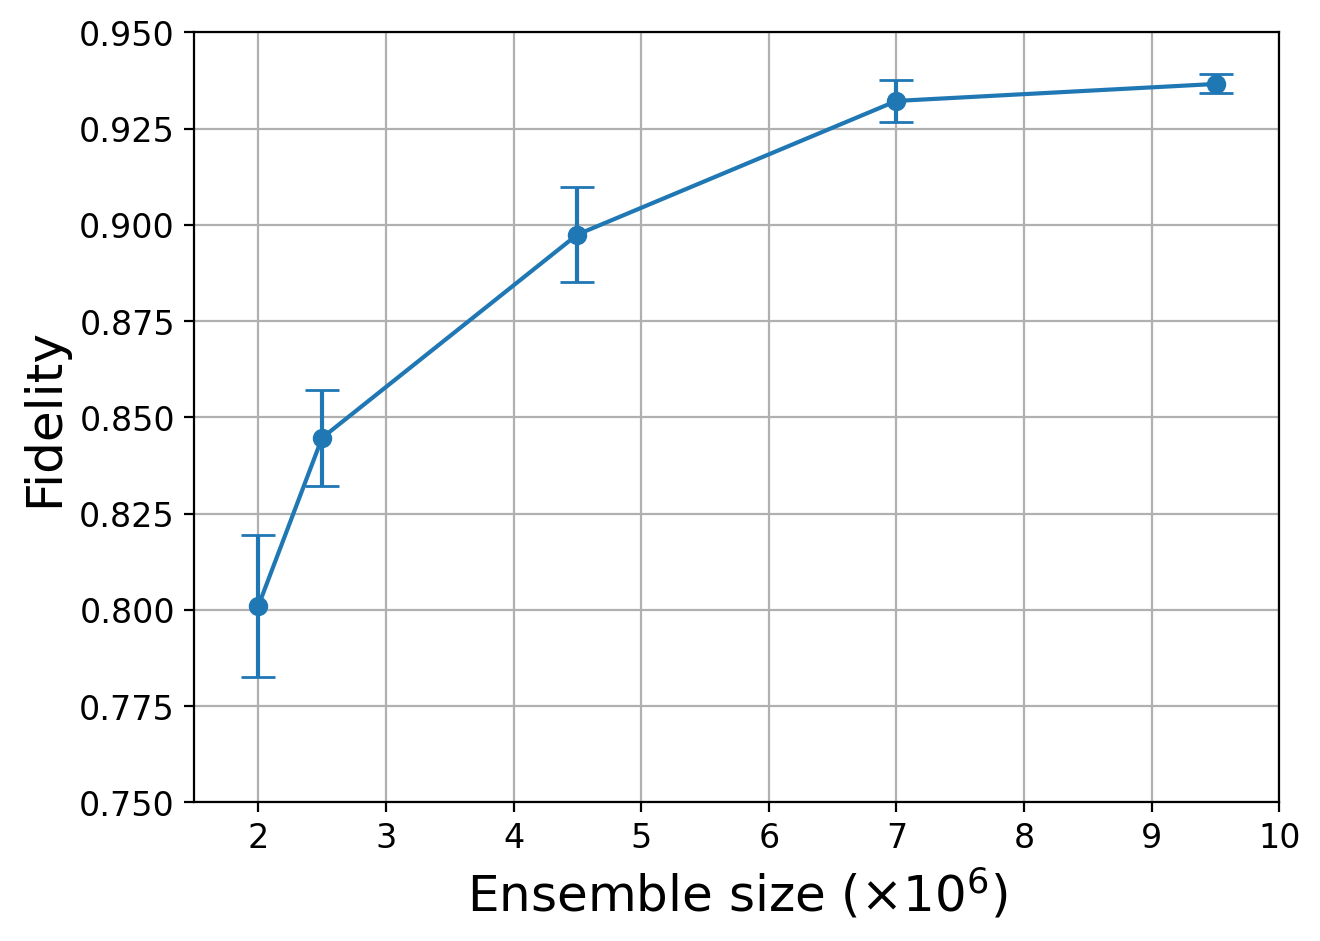

In [48]:
xtics=[25*8e4/1e6,25*10e4/1e6,25*18e4/1e6,25*28e4/1e6,25*38e4/1e6]

plt.figure(figsize=(7,5), dpi=200)

plt.errorbar(xtics,res_sher_2n_12qb,yerr=err_sher_2n_12qb,marker='o',capsize=6,capthick=1)

plt.ylim((0.75,0.95))
plt.xlim((1.5,10))
plt.xlabel(r'Ensemble size ($\times10^6$)', fontsize=18)
plt.ylabel(r'Fidelity', fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True)

plt.savefig(
    'Sherbrooke_2n_ensemble_size.png',          # Filename (can include path)
    dpi=300,               # Dots per inch (resolution)
    bbox_inches='tight',   # Minimize whitespace around plot
    #quality=95,            # For JPEG only (1-100)
    transparent=True,      # Make background transparent
    facecolor='white'      # Figure face color
)


plt.show()